# Imports

In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities

# Loading and Determining Population

In [35]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())
print(probs_dict.keys())
print(probs_dict['random'].keys())

dict_keys(['AggregatedPop1027', 'meuse', 'RegularPop1000', 'cluster', 'random', 'swiss', 'grid'])
dict_keys(['AggregatedPop1027', 'meuse', 'RegularPop1000', 'cluster', 'random', 'swiss', 'grid'])
dict_keys(['unequal', 'equal'])


In [ ]:
N = 100
n = 4
coords = coords_dict['cluster']
probs = probs_dict['cluster']['equal']
modified_probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, modified_probs)

[0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04]


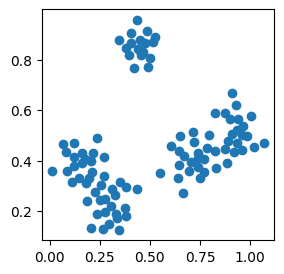

In [37]:
import matplotlib.pyplot as plt
x = coords[:, 0]
y = coords[:, 1]

plt.figure(figsize=(3,3))
plt.scatter(x, y)
plt.show()

# Building Initial Designs

In [38]:
orders = [
    # "lexico-yx",
    # "lexico-xy",
    # "random",
    # "angle_0",
    # "distance_0",
    # "projection",
    # "center",
    "spiral",
    # "max",
    # "snake",
    # "hilbert",
]

In [39]:
initial_designs = []
combines = list(itertools.product(orders, orders))
num_trials = 2
for units_order, zones_order in tqdm(combines, desc="Generating initial designs", total=len(combines), unit="orders"):
    best = None
    best_score = np.inf
    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n=n,
            n_zones=(2, 2),
            zone_builder='sweep',
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()

    initial_designs.append(gs.NewDesign(best))

    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n=n,
            n_zones=(1, 1),
            zone_builder='sweep',
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()

    initial_designs.append(gs.NewDesign(best))


Generating initial designs:   0%|          | 0/1 [00:00<?, ?orders/s]

Generating initial designs: 100%|██████████| 1/1 [00:04<00:00,  4.10s/orders]


In [40]:
for design in initial_designs:
    print(design.kmeans.all_samples.shape, design.kmeans.expected_moran_score())

(56, 4) -0.2970208008093929
(25, 4) -0.3248187979620539


# Run Astar

In [41]:
moran_criteria = gs.criteria.MoranCriteria()

In [42]:
astar = gs.search.AStar(
    initial_designs,
    moran_criteria
)

best initial criteria value -0.3248187979620539


In [43]:
astar.run(
    max_iterations = 200,
    num_new_nodes = 10,
    max_open_set_size = 1000,

    n_clusters_to_change_order_zone = 0,
    n_changes_in_order_of_zones = 0,

    n_clusters_to_change_order_units = 1,
    n_zones_to_change_order_units = 1,
    n_changes_in_order_of_units = 1,

    n_jobs=-1
)


parent node: -0.3248187979620539
iteration: 0, child node: -0.31452328120174533
iteration: 0, child node: -0.3222762123942923
iteration: 0, child node: -0.3260469015647827

iteration: 0, New best criteria value: -0.3260469015647827

iteration: 0, child node: -0.30913334547875826
iteration: 0, child node: -0.32732205286667027

iteration: 0, New best criteria value: -0.32732205286667027

iteration: 0, child node: -0.32813484581322405

iteration: 0, New best criteria value: -0.32813484581322405

iteration: 0, child node: -0.31024783582737914
iteration: 0, child node: -0.3125296629093377
iteration: 0, child node: -0.3248187979620539
iteration: 0, child node: -0.32284974034968683

parent node: -0.32813484581322405


/config/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


iteration: 1, child node: -0.31972017582657164
iteration: 1, child node: -0.34521725142367293

iteration: 1, New best criteria value: -0.34521725142367293

iteration: 1, child node: -0.3280748577526257
iteration: 1, child node: -0.32813484581322405
iteration: 1, child node: -0.3295062392043442
iteration: 1, child node: -0.33019100655214406
iteration: 1, child node: -0.3242538566198767
iteration: 1, child node: -0.32735657393652773
iteration: 1, child node: -0.3340500852421068
iteration: 1, child node: -0.32813484581322405

parent node: -0.34521725142367293
iteration: 2, child node: -0.352052174416496

iteration: 2, New best criteria value: -0.352052174416496

iteration: 2, child node: -0.3313751256638042
iteration: 2, child node: -0.3199923445321434
iteration: 2, child node: -0.34329649522455086
iteration: 2, child node: -0.32525353812638125
iteration: 2, child node: -0.34572687893933174
iteration: 2, child node: -0.3328828803052222
iteration: 2, child node: -0.3433495935601255
iterati

200

In [44]:
astar.best_criteria_value

-0.6690602691274303

In [45]:
astar.best_design.kmeans.score_summary_df()

,expected,std
measure,,
density,-0.051351,0.227265
moran,-0.669060,0.226896
local_balance,0.340266,0.064106
voronoi,0.119808,0.046111


In [50]:
np.mean(np.abs(astar.best_design.kmeans.fips - modified_probs))

np.float64(6.938893903907228e-18)

In [17]:
astar.best_design.kmeans.all_samples_probs.sum()

np.float64(1.000000000003)

# Run Bees

In [53]:
bee = gs.search.Bees(
    initial_designs,
    gs.criteria.MoranCriteria(),
    colony_size=20,
    limit=50,
)

Evaluating initial designs...
ABC initialized - Best initial criteria value: -0.3248187979620539


In [ ]:
bee.run(
    max_iterations = 1000,

    n_clusters_to_change_order_zone = 0,
    n_changes_in_order_of_zones = 0,

    n_clusters_to_change_order_units = 1,
    n_zones_to_change_order_units = 1,
    n_changes_in_order_of_units = 1,

    n_jobs=-1
)


Starting ABC with 20 food sources
Colony size: 20, Limit: 50

Iteration 1/1000
NEW BEST at iteration 1
Criteria value: -0.33067800
  Best: -0.330678, Avg: -0.310984

Iteration 2/1000
NEW BEST at iteration 2
Criteria value: -0.34561118
  Best: -0.345611, Avg: -0.315212

Iteration 3/1000
NEW BEST at iteration 3
Criteria value: -0.34561118
  Best: -0.345611, Avg: -0.315799

Iteration 4/1000
NEW BEST at iteration 4
Criteria value: -0.35258452
  Best: -0.352585, Avg: -0.317122

Iteration 5/1000
NEW BEST at iteration 5
Criteria value: -0.35487696
  Best: -0.354877, Avg: -0.318228

Iteration 6/1000
NEW BEST at iteration 6
Criteria value: -0.35677525
  Best: -0.356775, Avg: -0.321628

Iteration 7/1000
NEW BEST at iteration 7
Criteria value: -0.35720527
  Best: -0.357205, Avg: -0.322338

Iteration 8/1000
NEW BEST at iteration 8
Criteria value: -0.35720527
  Best: -0.357205, Avg: -0.324227

Iteration 9/1000
NEW BEST at iteration 9
Criteria value: -0.36883563
  Best: -0.368836, Avg: -0.328753

I